In [1]:
from spin_lattices import SpinLattice, KagomeLattice, SquareLattice, TriangularLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
import numpy as np
import numpy.typing as npt
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import itertools
from misc_utils import hadamard_transform_pytorch_inplace
import torch
import unittest
from tqdm.auto import tqdm
from fourier_supervised_cleanroom_2023_09_27 import get_lattice
from nn_supervised_reproduction import get_config, output_dir, default_config, SignDenseNetXor
from misc_utils import read_jsonl_to_df, keep_serializable, column_to, concat_columns
from parity import parity

In [2]:
df = (
    read_jsonl_to_df(output_dir.glob("*/results.jsonl"))
    .fillna(keep_serializable(default_config))
    .assign(
        full_arch=concat_columns(
            ["architecture", "xor_strategy", "n_xors", "xor_hamming_weight", "xor_sampling_power"]
        )
    )
)

In [18]:
df['architecture'].unique()

array(['dense', 'dense+xor', 'invariant_cnn'], dtype=object)

In [3]:
sns.catplot(
    df.query('architecture == "invariant_cnn"')
    .pipe(column_to(str, "dilations"))
    .query("epoch > 100"),
    x="dilations",
    y="test_overlap",
    kind="point",
)

KeyError: 'dilations'

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


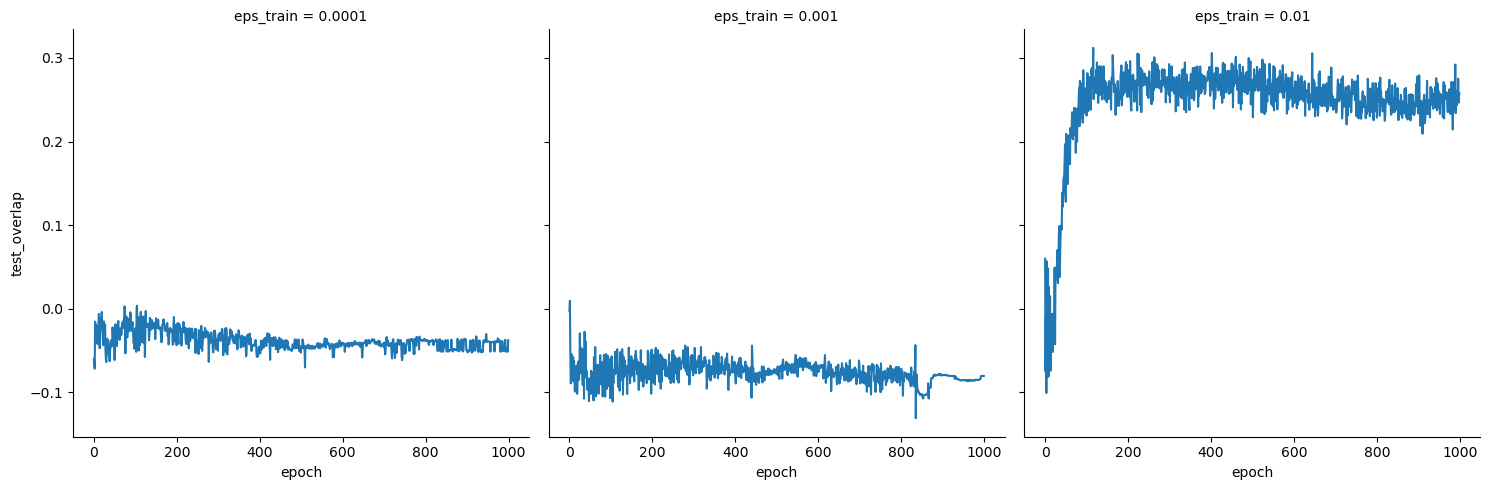

In [ ]:
sns.relplot(
    df.query('(lattice == "kagome2x4" and J2 == 1  and sampling_power_train == 2 )'),
    x='epoch',
    y='test_overlap', kind='line', col='eps_train')


/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


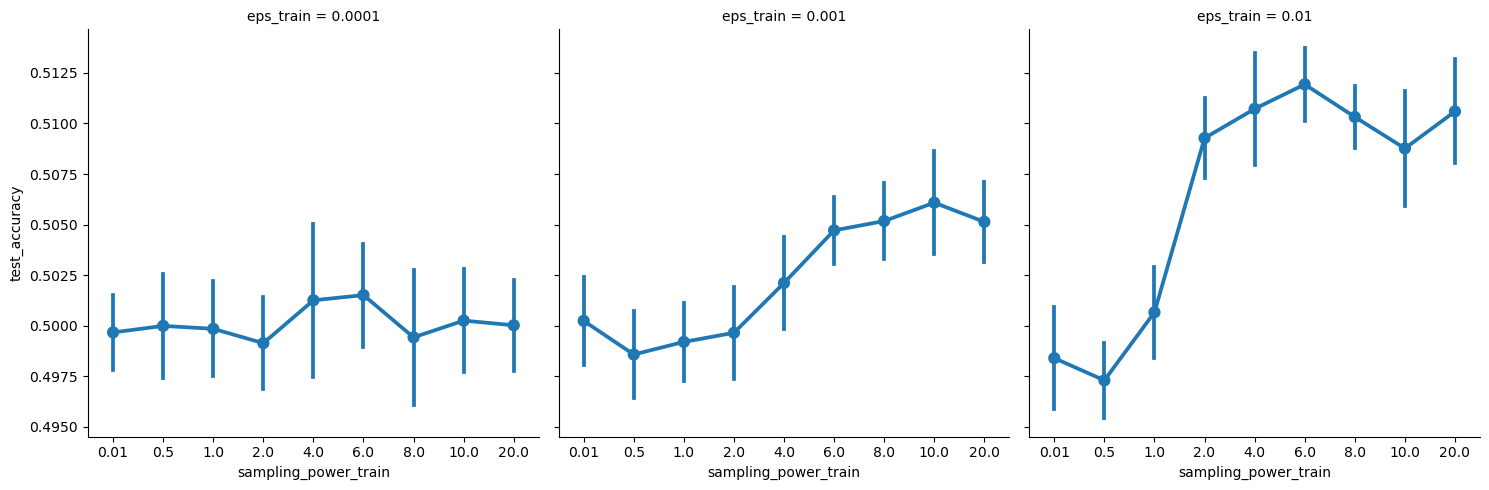

In [ ]:
sns.catplot(
    (
        df.query('(lattice == "kagome2x4" and J2 >= 0.8 and epoch >= 200)')
    ),
    x="sampling_power_train",
    y="test_accuracy",
    col="eps_train",
    kind='point',
    errorbar='sd',
)
#plt.savefig("fig/fourier_supervised_cleanroom-overlap-vs-sampling_power_train.pdf")

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


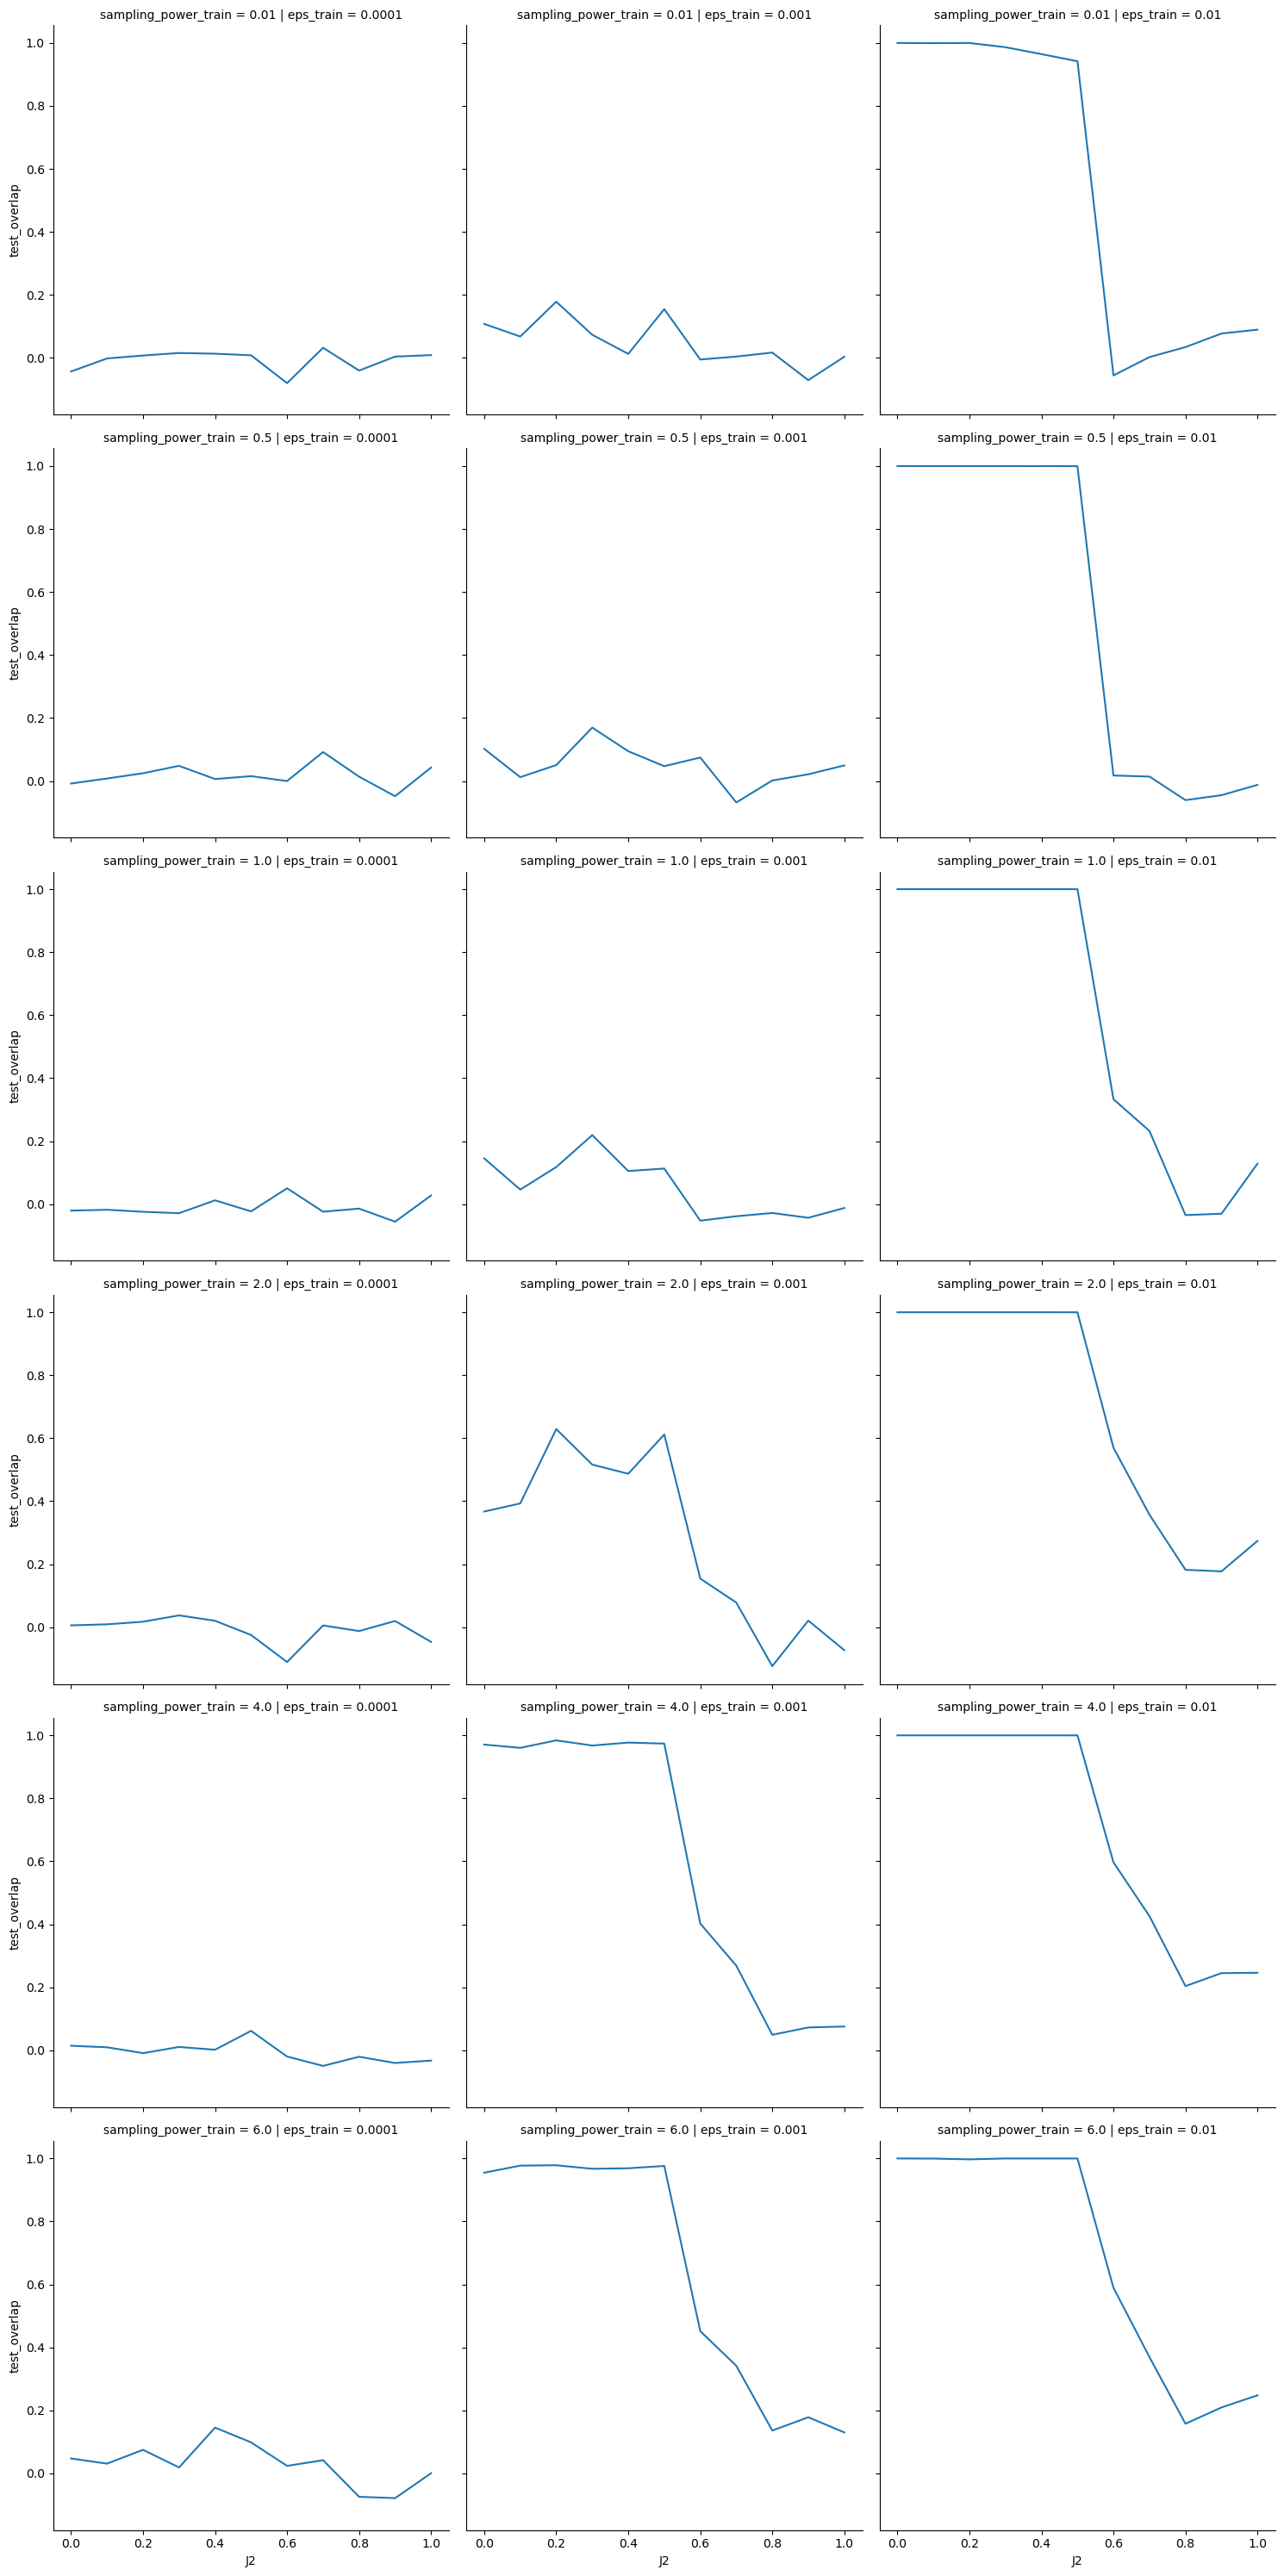

In [ ]:
sns.relplot(
    df.query('lattice == "kagome2x4" and epoch == 500'),
    x="J2",
    y="test_overlap",
    col='eps_train',
    kind='line',
    row='sampling_power_train',
)

In [15]:
# show all columns
pd.set_option('display.max_columns', None)

In [37]:
df.query(
    'lattice == "kagome2x4" '
    "and J2 == 1 "
    "and epoch == 299 "
    "and sampling_power_train == 2 "
    "and eps_train == 0.01 "
).groupby('full_arch')[['test_overlap', 'test_accuracy']].agg(['mean', 'std']).sort_values(('test_overlap', 'mean'))

test_overlap           test_accuracy  \
                                              mean       std          mean   
full_arch                                                                    
dense+xor_hamming_weight_8.0_2.0_nan      0.125488  0.034069      0.505260   
dense+xor_hamming_weight_4.0_2.0_nan      0.195763  0.021026      0.507698   
dense+xor_hamming_weight_1.0_2.0_nan      0.215771  0.035868      0.510060   
dense+xor_hamming_weight_2.0_2.0_nan      0.230758  0.022591      0.509044   
dense_nan_nan_nan_nan                     0.260210  0.034091      0.506800   
dense+xor_hamming_weight_1.0_12.0_nan     0.407443  0.100511      0.518776   
dense+xor_uniform_1.0_nan_nan             0.445118  0.134693      0.520420   
dense+xor_uniform_2.0_nan_nan             0.446269  0.096828      0.522218   
dense+xor_fourier_weight_1.0_nan_2.0      0.447176  0.146183      0.521460   
dense+xor_hamming_weight_8.0_12.0_nan     0.473768  0.061130      0.522092   
dense+xor_uniform_4.0_nan_nan             0.475128  0.054192      0.522700   
dense+xor_uniform_8.0_nan_nan             0.487356  0.061451      0.523672   
dense+xor_hamming_weight_2.0_12.0_nan     0.516482  0.095312      0.526266   
dense+xor_hamming_weight_4.0_12.0_nan     0.518587  0.050486      0.526836   
dense+xor_fourier_weight_2.0_nan_2.0      0.559124  0.095102      0.531300   
dense+xor_fourier_weight_8.0_nan_2.0      0.575952  0.059532      0.531200   
dense+xor_fourier_weight_4.0_nan_2.0      0.601630  0.024773      0.531878   

                                                 
                                            std  
full_arch                                        
dense+xor_hamming_weight_8.0_2.0_nan   0.001852  
dense+xor_hamming_weight_4.0_2.0_nan   0.002319  
dense+xor_hamming_weight_1.0_2.0_nan   0.002325  
dense+xor_hamming_weight_2.0_2.0_nan   0.002591  
dense_nan_nan_nan_nan                  0.000970  
dense+xor_hamming_weight_1.0_12.0_nan  0.007044  
dense+xor_uniform_1.0_nan_nan          0.009058  
dense+xor_uniform_2.0_nan_nan          0.005790  
dense+xor_fourier_weight_1.0_nan_2.0   0.009740  
dense+xor_hamming_weight_8.0_12.0_nan  0.004244  
dense+xor_uniform_4.0_nan_nan          0.003499  
dense+xor_uniform_8.0_nan_nan          0.004814  
dense+xor_hamming_weight_2.0_12.0_nan  0.006977  
dense+xor_hamming_weight_4.0_12.0_nan  0.003975  
dense+xor_fourier_weight_2.0_nan_2.0   0.008507  
dense+xor_fourier_weight_8.0_nan_2.0   0.004410  
dense+xor_fourier_weight_4.0_nan_2.0   0.004104

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


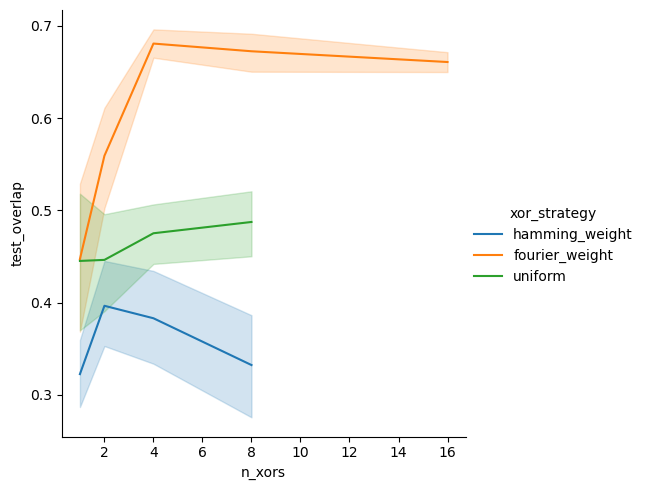

In [63]:
sns.relplot(df.query(
        'lattice == "kagome2x4" '
        "and J2 == 1 "
        "and epoch == 299 "
        "and sampling_power_train == 2 "
        "and eps_train == 0.01"   
    ),
    x='n_xors',
    y='test_overlap',
    kind='line',
    hue='xor_strategy',
)

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


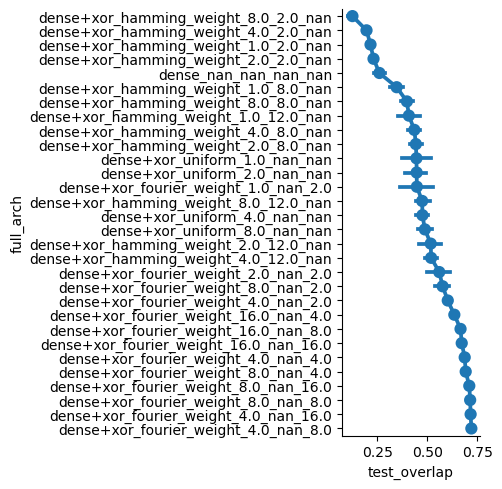

In [65]:
sns.catplot(
    df.query(
        'lattice == "kagome2x4" '
        "and J2 == 1 "
        "and epoch == 299 "
        "and sampling_power_train == 2 "
        "and eps_train == 0.01"
       
    ).pipe(column_to(str, "eps_train")),
    y="full_arch",
    x="test_overlap",
    kind="point",
    order=list(
        df.query(
            'lattice == "kagome2x4" '
            "and J2 == 1 "
            "and epoch == 299 "
            "and sampling_power_train == 2 "
            "and eps_train == 0.01"
        )
        .pipe(column_to(str, "eps_train"))
        .groupby("full_arch")["test_overlap"]
        .mean()
        .sort_values()
        .index
    ),
)

In [59]:
selected_columns = ["parity degree", "sampling power", "number of parity inputs"]
df_selection = (
    df.query(
        'lattice == "kagome2x4" '
        "and J2 == 1 "
        "and epoch == 299 "
        "and sampling_power_train == 2 "
        "and eps_train == 0.01"
    )
    .rename(
        columns={
            "xor_hamming_weight": "parity degree",
            "xor_sampling_power": "sampling power",
            "n_xors": "number of parity inputs",
            "test_overlap": "test overlap",
            "test_accuracy": "test accuracy",
        }
    )
    .groupby(selected_columns, dropna=False)[["test overlap", "test accuracy"]]
    .agg(["mean", "sem"])
    .reset_index()
    .fillna({"number of parity inputs": 0})
    .fillna("")
    .sort_values(selected_columns)
    .reset_index(drop=True)
)

In [60]:
def get_latex(df):
    def int_ignore_error(x):
        try:
            return int(x)
        except ValueError:
            return x

    df = df.copy()
    # Find the max values for highlighting
    max_overlap = df[("test overlap", "mean")].max()
    max_accuracy = df[("test accuracy", "mean")].max()

    # Apply LaTeX bold formatting to max values
    df[("test overlap", "mean")] = df[("test overlap", "mean")].apply(
        lambda x: f"\\textbf{{{x:.4f}}}" if x == max_overlap else x
    )
    df[("test accuracy", "mean")] = df[("test accuracy", "mean")].apply(
        lambda x: f"\\textbf{{{x:.4f}}}" if x == max_accuracy else x
    )

    df["parity degree"] = df["parity degree"].apply(int_ignore_error)
    df["sampling power"] = df["sampling power"].apply(int_ignore_error)
    df["number of parity inputs"] = df["number of parity inputs"].apply(int_ignore_error)
    df.rename(
        columns={
            "number of parity inputs": "\\# parities",
            # "sampling power": "power",
            # "parity degree": "degree",
        },
        inplace=True,
    )
    # Convert DataFrame to LaTeX
    latex_table = df.to_latex(index=False, escape=False, float_format="%.4f")
    return latex_table


print(get_latex(df_selection))

\begin{tabular}{llrlrlr}
\toprule
parity degree & sampling power & \# parities & \multicolumn{2}{r}{test overlap} & \multicolumn{2}{r}{test accuracy} \\
 &  &  & mean & sem & mean & sem \\
\midrule
2 &  & 1 & 0.2158 & 0.0108 & 0.5101 & 0.0007 \\
2 &  & 2 & 0.2308 & 0.0071 & 0.5090 & 0.0008 \\
2 &  & 4 & 0.1958 & 0.0066 & 0.5077 & 0.0007 \\
2 &  & 8 & 0.1255 & 0.0108 & 0.5053 & 0.0006 \\
8 &  & 1 & 0.3463 & 0.0173 & 0.5146 & 0.0014 \\
8 &  & 2 & 0.4423 & 0.0166 & 0.5209 & 0.0010 \\
8 &  & 4 & 0.4346 & 0.0168 & 0.5185 & 0.0008 \\
8 &  & 8 & 0.3976 & 0.0174 & 0.5184 & 0.0009 \\
12 &  & 1 & 0.4074 & 0.0303 & 0.5188 & 0.0021 \\
12 &  & 2 & 0.5165 & 0.0301 & 0.5263 & 0.0022 \\
12 &  & 4 & 0.5186 & 0.0160 & 0.5268 & 0.0013 \\
12 &  & 8 & 0.4738 & 0.0193 & 0.5221 & 0.0013 \\
 & 2 & 1 & 0.4472 & 0.0441 & 0.5215 & 0.0029 \\
 & 2 & 2 & 0.5591 & 0.0301 & 0.5313 & 0.0027 \\
 & 2 & 4 & 0.6016 & 0.0078 & 0.5319 & 0.0013 \\
 & 2 & 8 & 0.5760 & 0.0188 & 0.5312 & 0.0014 \\
 & 4 & 4 & 0.6862 & 0.0058 & 0